# Authorship Verification

## Differences with the main notebook

The *Sidrac*, a prose text with a rhymed pro- and epilogue is included in this notebook, which complicates the analysis. Some functions are added to handle the text in different ways:

1) Option to remove the prose part of the *Sidrac* and only load in the (rhymed) pro- and epilogue;
2) Option to remove the rhyme words in all of the other works;
3) Option to limit the amount of segments per title in the scatterplot (otherwise e.g. *Spiegel Historiael* would dominate the plot).

Currently, option 2 and 3 are in use. Option 1 left too little data (222 verses).

## Loading in the needed libraries

In [1]:
import os
import re
from collections import Counter
import glob

from itertools import combinations, product

import lxml.etree
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_colwidth', 0)
import numpy as np
np.random.seed(18012023)
import seaborn as sb

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

import scipy.spatial.distance as scidist

from bokeh.models import HoverTool, ColumnDataSource
from bokeh.plotting import figure, show, output_file, save
from bokeh.io import output_file, show, save, output_notebook
from bokeh.plotting import figure
from bokeh.models import Axis

import mpl_axes_aligner

## Loading in the data  and metdata

#### Option to only load in the rhyme (option 1)

In [2]:
def load_verses(filepath, rm_interpol=True, rm_prose=False):
    tree = lxml.etree.parse(filepath)
    
    if rm_interpol:
        for interpolation in tree.xpath("//interpolation"):
            interpolation.getparent().remove(interpolation)
            
    if rm_prose:
        for prose in tree.xpath("//prose"):
            prose.getparent().remove(prose)
    
    verses = []
    
    for line_node in tree.iterfind('//l'):
        verse = []
        
        lemma_tags = [l.text if l.text else "" for l in line_node.iterfind('.//lemma')]
        pos_tags = [p.text if p.text else "" for p in line_node.iterfind('.//pos')]
        
        for lemma, pos in zip(lemma_tags, pos_tags):
            lemma = lemma or ""  # Ensure lemma is not None
            pos = pos or ""      # Ensure pos is not None
            
            for l, p in zip(lemma.split('+'), pos.split('+')):
                if p == 'NOU-P':
                    verse.append(('NOU-P', 'NOU-P'))
                else:
                    verse.append((l, p))
        
        verses.append(verse)
    
    return verses

In [3]:
meta_df = pd.read_excel('../data/metadata_corrected.xlsx')
meta_df = meta_df[meta_df['genre'].isin(['Epiek', 'Proza'])]
meta_df = meta_df[meta_df['exclude'] != 'x']
meta_df.sample(10)

,id,title,author,provenance,date_range,genre,subgenre,exclude
80,grimbergse_oorlog_cont,Grimbergse oorlog (cont),NaN,cdrom-mnl,1300-1350,Epiek,Historiografie,NaN
166,roman_van_perchevael,Perchevael,NaN,cdrom-mnl,1300-1350,Epiek,Arthur,NaN
11,bediedenisse_van_der_missen,Bediedenisse van der missen,NaN,cdrom-mnl,1340-1360,Epiek,Religie,NaN
104,roman_van_lancelot_fragm_br,Lancelot,NaN,cdrom-mnl,1300-1350,Epiek,Arthur,NaN
123,madelgijs_fragm_lo,Madelgijs,NaN,cdrom-mnl,1350-1400,Epiek,Karel,NaN
45,"Der naturen bloeme, handschrift D",Der naturen bloeme,Jacob van Maerlant,CG1,1287-1287,Epiek,Didactiek,NaN
221,spiegel_historiael__2,Spiegel historiael (P2),Philip Utenbroeke,cdrom-mnl,1393-1402,Epiek,Historiografie,NaN
99,roman_van_jonathas_ende_rosafiere_fragm_a,Jonathas ende Rosafiere,NaN,cdrom-mnl,1500-1520,Epiek,Ridder,NaN
40,cyromanchie_van_den_pape_van_den_hamme_chiromantie,Cyromanchie van den pape van den Hamme,NaN,cdrom-mnl,1440-1460,Epiek,Didactiek,NaN
155,ongeidentificeerd_6,Ongeïdentificeerd (6),NaN,cdrom-mnl,1375-1400,Epiek,Karel,NaN


#### Works are loaded in, including the Sidrac:

In [4]:
meta_df.tail()

,id,title,author,provenance,date_range,genre,subgenre,exclude
282,willem_van_oringen,Willem van Oringen,NaN,cdrom-mnl,1300-1350,Epiek,Karel,NaN
285,Wrake van Ragisel,Wrake van Ragisel,NaN,CG1,1280-1260,Epiek,Arthur,NaN
286,wrake_van_ragisel,Wrake van Ragisel,NaN,cdrom-mnl,1300-1350,Epiek,Arthur,NaN
287,Merlijn-Velthem,Merlijn-continuatie,Lodewijk van Velthem,cdrom-mnl,1415-1435,Epiek,Arthur,NaN
288,sidrac,Sidrac,Jan van Boendale,cdrom-mnl,1318-1329,Proza,Didactiek,NaN


In [5]:
works = []
rm_interpol = True

pbar = tqdm(meta_df.groupby('title'), desc='description')
for title, group in pbar:
    pbar.set_description('{message: <{width}}'.format(message=title[:50], width=50))
    meta = list(group.sample(1)[['title', 'author', 'genre', 'subgenre']].values[0])
    words = []
    
    for id_ in sorted(group['id']):
        try:
            words.extend(load_verses(f'../data/xml_galahad_BY-split/{id_}.xml', rm_interpol=rm_interpol))
        except OSError:
            print(f'- Could not load {id_}')
            continue
    
    works.append(meta + [words])

work_df = pd.DataFrame(works, columns=['title', 'author', 'genre', 'subgenre', 'text'])

Wrake van Ragisel                                 : 100%|█| 165/165 [00:09<00:00


In [6]:
work_df[work_df['title'] == 'Sidrac']

title            author  genre   subgenre  \
121  Sidrac  Jan van Boendale  Proza  Didactiek   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

#### Option to delete all rhyme words in the other texts (might be more fair towards Sidrac) (option 2)


## Segmentation 

In [7]:
def segment(work_df, rhyme_only=True, incl_lemma=True, incl_pos=False, segment_length = 2000, min_length=1364):        
    if not (incl_pos or incl_lemma):
        raise ValueError('incl_lemma OR incl_pos must be set to True')

    segments = []

    for _, row in tqdm(list(work_df.iterrows())):
        if rhyme_only:
            text = [verse[-1] for verse in row['text']]
        else:
            text = [item for sublist in row['text'] for item in sublist]
        
        if incl_lemma and incl_pos:
            text = ['@'.join(p) for p in text]
        elif incl_lemma:
            text = [p[0] for p in text]
        else:
            text = [p[1] for p in text]

        meta = [row['title'], row['author'], row['genre'], row['subgenre']]
        
        if row['title'] == 'Van Saladijn':
            text = text[::2] + text[1::2]
        
        if segment_length:
            if len(text) < segment_length:
                continue
            si, ei, idx = 0, segment_length, 1
            while ei < len(text):
                segments.append(meta + [idx, text[si:ei]])
                idx += 1
                si += segment_length
                ei += segment_length
        else:
            if len(text) >= min_length:
                segments.append(meta + [0, text])

    return pd.DataFrame(segments, columns=['title', 'author', 'genre', 'subgenre', 'segment-idx', 'text'])

segment_df = segment(work_df, rhyme_only=False, incl_pos=False, segment_length=5000)
segment_df.sample(5)

100%|████████████████████████████████████████| 165/165 [00:00<00:00, 647.25it/s]


,title,author,genre,subgenre,segment-idx,text
148,Der naturen bloeme,Jacob van Maerlant,Epiek,Didactiek,7,"[stonde, plot, en, bidden, het, zwoes, kind, zo, komen, hij, tulp, ginder, die, roek, oegen, op, hij, mede, dit, zijn, oorlog, zonder, uurde, in, doorn, ineren, hij, absaluen, des, atti, zezel, doen, want, hij, destelen, en, doorn, uurteren, daar, hij, die, wogel, mede, ineren, NOU-P, zijn, die, leeuwerik, die, zoet, zingte, als, ik, merken, en, groeten, de, dag, alse, zij, ontspringen, in, die, tijd, dat, zij, zinken, zelden, eisen, in, het, jaar, zonen, zinken, schijnen, de, zon, klaar, zonder, alleen, alzo, vermuiten, haar, zang, zijn, groot, deduut, newaar, zo, nes, zo, mild, niet, zo, zeer, zo, bijten, wogel, ontzien, dat, ...]"
47,Brabantsche yeesten (B1-3),Jan van Boendale,Epiek,Historiografie,5,"[vernemen, dat, keizer, NOU-P, zijn, daar, de, brief, geven, zij, hij, klaar, want, menig, daar, geen, Grieks, kunnen, geven, men, daar, ter, zelf, stonde, turpijn, dat, hij, de, lieden, in, die, landswijze, zullen, beduiden, en, als, NOU-P, de, brief, ontbinden, wenen, NOU-P, alte, hand, om, dat, die, heiden, bezitten, ons, heer, graf, met, onmaat, en, al, dat, volk, worden, in, roer, en, bidden, de, keizer, dat, hij, er, voeren, die, keizer, NOU-P, dat, hou, zijn, NOU-P, geven, te, hand, uit, een, gebod, dat, al, die, gene, die, onder, hij, liggen, en, wapen, mogen, dragen, met, hij, in, de, schaar, jegen, ...]"
176,Dietsche doctrinale,NaN,Epiek,Didactiek,4,"[vrouw, NOU-P, NOU-P, zeggen, nog, hier, af, gelijk, dat, een, bezaad, hof, daar, geen, tuin, om, ne, gaan, in, vrees, onbewaard, staan, alzo, zijn, het, het, huis, de, tijd, gewis, daar, geen, vroed, wijf, ne, zijn, want, zij, zijn, in, al, nood, haar, man, een, hulp, help, groot, en, zonderling, een, ziek, man, zekerlijk, hij, ne, kunnen, rast, gehebben, noch, vrede, daar, ne, zij, een, wijf, mede, de, wijf, lijf, de, zijde, wijzen, dat, de, man, lijf, zijn, en, de, de, man, lijf, alzo, zijn, de, wijf, lijf, daar, toe, en, want, zij, dus, samen, leven, zo, moeten, elk, ander, geven, ...]"
117,Der leken spieghel,Jan van Boendale,Epiek,Didactiek,14,"[geboren, deze, maken, alzo, wij, het, schouwen, die, kerk, van, ons, vrouw, over, die, tibure, die, rivier, en, ook, quatertemper, vuur, zetten, hij, in, de, jaar, hij, sterven, heilig, martelaar, toen, hij, u, jaar, paus, hebben, zijn, twee, maand, tien, dag, als, men, lezen, NOU-P, worden, paus, toen, die, eerst, de, naam, hebben, alzo, geboren, uit, de, roem, de, stad, deze, ordineren, ook, dat, dat, gewijd, vat, zullen, tennen, zijn, zelfrijn, of, gouden, NOU-P, bekeren, hij, die, edel, zijn, en, vrij, NOU-P, NOU-P, bruidegom, en, geven, hij, dat, kerstendom, die, zo, heilig, worden, daar, naar, dat, hij, sterven, martelaar, deze, ...]"
626,Spiegel historiael (P1-P4),Jacob van Maerlant,Epiek,Historiografie,28,"[uitnemend, groet, die, ik, boven, al, ding, zijn, zoet, doen, dorsen, gene, wijf, niet, zoeken, aan, ons, vrouw, meer, met, vloek, en, gemoeten, dat, wijf, op, een, tijd, en, spreken, als, haar, geven, die, nijd, ai, vuil, vrouwe, dorper, en, kwaad, wat, gij, mij, al, leed, beraden, dat, gij, ik, nemen, mijn, man, dat, ik, met, de, wet, gewinnen, nochtan, ne, schuwen, gij, ik, niet, hoe, gaarne, doen, ik, u, verdriet, want, gij, nemen, ik, al, dag, mijn, blijdschap, dat, zijn, mijn, klaag, ik, hebben, een, troost, alleen, op, NOU-P, de, maagd, rein, om, ik, te, wreken, dat, toren, maar, ...]"


In [8]:
len(segment_df[segment_df['title'].str.contains('idrac')]['text'].iloc[0])

5000

## Combinations

In [9]:
calib_df = segment_df[
    (segment_df['author'].isin({'Jacob van Maerlant', 'Lodewijk van Velthem'})) | 
    (segment_df['title'].isin({'Jans teesteye'}))]
calib_df = calib_df[calib_df['title'] != 'Torec']
calib_df = calib_df[calib_df['title'] != 'Merlijn']

trg_df = segment_df[segment_df['title'].isin({#'Brabantsche yeesten (B1-3)', 
                                              #'Brabantsche yeesten (B4-5)',
                                              'Brabantsche yeesten (B5)',
                                              'Korte kroniek van Brabant (korte versie 1)',
                                              #'Korte kroniek van Brabant (lange versie)',
                                              'Der leken spieghel',
                                              'Jans teesteye',
                                              'Van den derden Eduwaert',
                                              'Melibeus',
                                              'Boec Exemplaer',
                                              'Dietsche doctrinale',
                                              'Boec vander wraken',
                                              'Sidrac'
                                             })] 

## Interpolations

The following interpolations are removed from the works. Based on Vandyck, C., & Kestemont, M. (2024). Een auteur van formaat. Een attributie-onderzoek naar het oeuvre van de Limborch-dichter. Spiegel Der Letteren, 66(2), 111–167. https://doi.org/10.2143/SDL.66.2.3293546)

Historie van Troyen (De Pauw & Gailliard 1889-1892, vs. 14587, vs. 16492, vs. 28332)

* vanaf vs. 14591 (Dies is leden menghen dach) t.e.m. vs. 15858 (Sonder haere beider lachter), ed. De Pauw & Gailliard 1889-1892.
* vanaf vs. 16493 (Daer waster veel syt, seker des) t.e.m. vs. 17500 (Dat seit Dares diet ons bescreef.), ed. De Pauw & Gailliard 1889-1892.
* vanaf vs. 28336 (Die werlt is gedeilt in drien) t.e.m. vs. 29344 (Sy en doyet gheen tyt), ed. De Pauw & Gailliard 1889-1892.

Spiegel Historiael, Vijfde Partie (Besamusca 2009, 83)

* vanaf boek I, kap. 40-46, vs. 2818 (Die derde Heinric van Brabant) t.e.m. vs. 3543 (Mar hier gaen vore ander dinge), ed. Vander Linden e.a. 1906-1938
* vanaf boek II, kap. 44-55, vs. 3213 (Na dit doen, dit es waer) t.e.m. vs. 3976 (Ward met enen stride gehint), ed. Vander Linden e.a. 1906-1938. 
* vanaf boek III, kap. 2-21, vs. 71 (In desen tiden, alse nu, gelach) t.e.m. vs. 1403 (In andren landen ende andren lieden), ed. Vander Linden e.a. 1906-1938.
* vanaf boek IV, vs. 1 (Nu es die tijt so verre comen) t.e.m. vs. 5329 (Den viften boec ende, ende volmaken), ed. Vander Linden e.a. 1906-1938.

Boec vander Wrake (Van Anrooij 1995, 44)

* vanaf boek III, vs. 2273 (Die hem wel bepeynsen soude) t.e.m. vs. 2490 (Amen seghet allegader. Amen), ed. Snellaert 1869.

Der vrouwen heimelijcheit (Van Doorn & Kuiper 1976-1977, 539) 

* vanaf vs. 824 (Ic soude u leeren, sonder waen) t.e.m. vs. 925 (Maer van den magdekine niet so saen,), ed. Blommaert 1846.

Dietsche Lucidarius (Klunder 2005, 80-88)30

* vanaf vs. 357 (Clerc, die here, die niene verstarf ) t.e.m. vs. 436 (Om die genuechte van aertrike), ed. Blommaert 1851.
* vanaf vs. 889 (Lieve meester, maect mi wijs) t.e.m. vs. 1026 (Mit saligen sielen scone;), ed. Blommaert 1851.
* vanaf vs. 4680 (Of men den lichame in ’t kerchof ) t.e.m. vs. 4810 (Daer die engelen Gode loven), ed. Blommaert 1851.

In [10]:
calib_df[['author', 'title']].value_counts()

author                title                          
Jacob van Maerlant    Spiegel historiael (P1-P4)         98
                      Historie van Troyen                43
                      Rijmbijbel                         38
Lodewijk van Velthem  Merlijn-continuatie                32
                      Spiegel historiael (P5)            22
Jacob van Maerlant    Der naturen bloeme                 18
                      Alexanders geesten                 15
                      Sinte Franciscus leven             11
Lodewijk van Velthem  Spiegel historiael (P4)            7 
Jan van Boendale      Jans teesteye                      4 
Jacob van Maerlant    Heymelijchede der heymelijcheit    2 
Name: count, dtype: int64

In [11]:
trg_df[['title']].value_counts()

title                   
Der leken spieghel          23
Sidrac                      18
Dietsche doctrinale         7 
Boec vander wraken          6 
Brabantsche yeesten (B5)    4 
Jans teesteye               4 
Melibeus                    4 
Van den derden Eduwaert     1 
Name: count, dtype: int64

In [12]:
combos = []
authors_titles = [g for g, _ in calib_df.groupby(['author', 'title'])]
for c1, c2 in combinations(authors_titles, 2):
    if c1[0] == c2[0]:
        combos.append((c1[1], c2[1], 'S'))
    else:
        combos.append((c1[1], c2[1], 'D'))

combos = pd.DataFrame(combos, columns=['title1', 'title2', 'authorship'])
print(combos['authorship'].value_counts())
combos.sample(5)

authorship
D    31
S    24
Name: count, dtype: int64


,title1,title2,authorship
13,Der naturen bloeme,Sinte Franciscus leven,S
11,Der naturen bloeme,Historie van Troyen,S
22,Heymelijchede der heymelijcheit,Spiegel historiael (P1-P4),S
41,Sinte Franciscus leven,Jans teesteye,D
20,Heymelijchede der heymelijcheit,Rijmbijbel,S


In [13]:
def identity(x):
    return x

def bigrams(text):
    text = text.split()
    for i in range(len(text)-1):
        if 'NOU-P' not in text[i:i+2]:
            yield '-'.join((sorted(text[i:i+2])))
            
def unigrams(text):
    words = text.split()
    for word in words:
        if 'NOU-P' not in word:
            yield word
            
params = {'use_idf': True,
          'max_features': 100,
          'analyzer': unigrams,
          'min_df': 5}

vectorizer = TfidfVectorizer(**params)
vectorizer.fit(calib_df['text'].astype(str).tolist() + trg_df['text'].astype(str).tolist())
X = vectorizer.transform(calib_df['text'].astype(str).tolist()).toarray()
X.shape

(290, 100)

In [14]:
# Sanity check to make sure all proper nouns are ignored and not present in the vector (important for Korte Kroniek)

# get the features from the vectorizer
feature_names = vectorizer.get_feature_names_out()
contains_nou_p = any("NOU-P" in feature for feature in feature_names)

# result
print("Does the feature list contain 'NOU-P'?", contains_nou_p)

Does the feature list contain 'NOU-P'? False


### Calibration

In [15]:
calib_distances = []

for idx, row in combos.iterrows():
    AX = X[calib_df['title'] == row['title1']]
    BX = X[calib_df['title'] == row['title2']]
    
    for distance in scidist.cdist(AX, BX, metric='cosine').flatten():
        calib_distances.append((row['title1'], row['title2'], row['authorship'], distance))

calib_distances = pd.DataFrame(calib_distances, columns=['title1', 'title2', 'authorship', 'distance'])
calib_distances = calib_distances[~calib_distances['distance'].isna()]
calib_distances

,title1,title2,authorship,distance
0,Alexanders geesten,Der naturen bloeme,S,0.107436
1,Alexanders geesten,Der naturen bloeme,S,0.072796
2,Alexanders geesten,Der naturen bloeme,S,0.089410
3,Alexanders geesten,Der naturen bloeme,S,0.071111
4,Alexanders geesten,Der naturen bloeme,S,0.104188
...,...,...,...,...
34473,Spiegel historiael (P4),Spiegel historiael (P5),S,0.058239
34474,Spiegel historiael (P4),Spiegel historiael (P5),S,0.076652
34475,Spiegel historiael (P4),Spiegel historiael (P5),S,0.068021
34476,Spiegel historiael (P4),Spiegel historiael (P5),S,0.059948


max(f1)=0.0 @ theta=0.9179


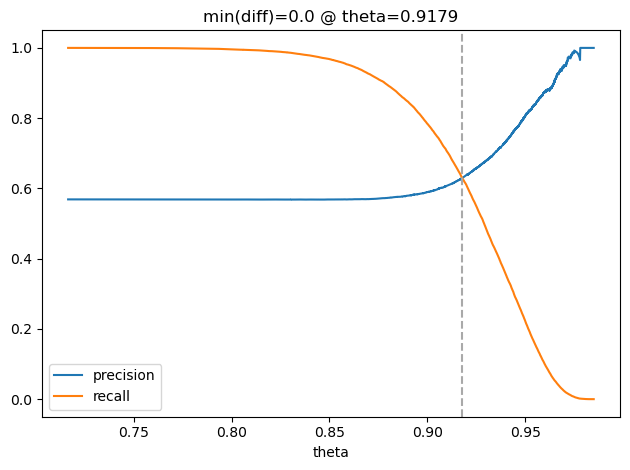

In [16]:
distances = 1 - np.array(calib_distances['distance'])
relevances = calib_distances['authorship']
precisions, recalls, thresholds = precision_recall_curve(relevances, distances, pos_label='S')
diffs = np.abs(precisions - recalls)
max_diff_idx = np.array(diffs).argmin()
max_diff = diffs[max_diff_idx]
max_diff_th = thresholds[max_diff_idx]
print(f'max(f1)={round(max_diff, 4)} @ theta={round(max_diff_th, 4)}')

plt.plot(thresholds, precisions[:-1], label='precision')
plt.plot(thresholds, recalls[:-1], label='recall')
plt.axvline(max_diff_th, ls='--', c='darkgrey')
plt.gca().set_xlabel('theta')
plt.gca().legend()
plt.title(f'min(diff)={round(max_diff, 4)} @ theta={round(max_diff_th, 4)}')
plt.tight_layout()

In [17]:
calib_thresh = 1 - max_diff_th
calib_thresh

0.08214924387302691

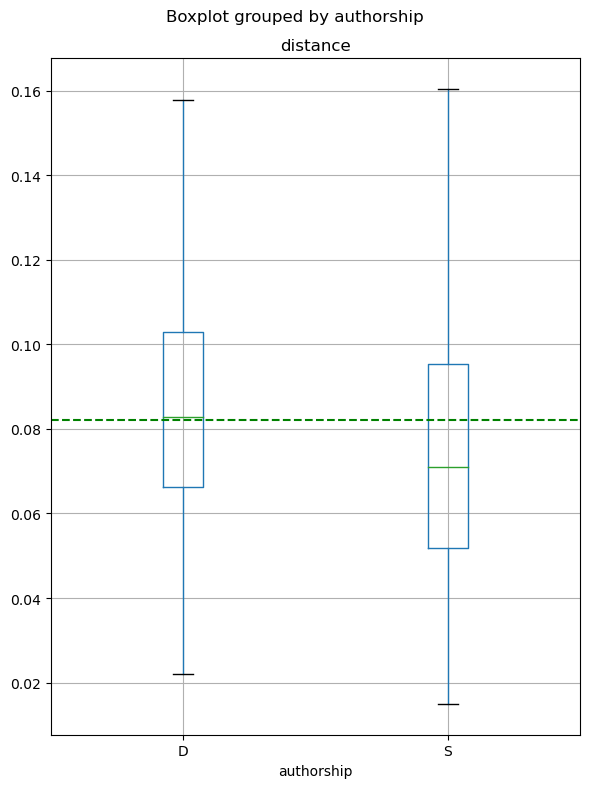

In [18]:
calib_distances.boxplot('distance', 'authorship', figsize=(6, 8), showfliers=False)
plt.axhline(calib_thresh, c='green', ls='--')
plt.tight_layout();

### Applied to the Antwerp School

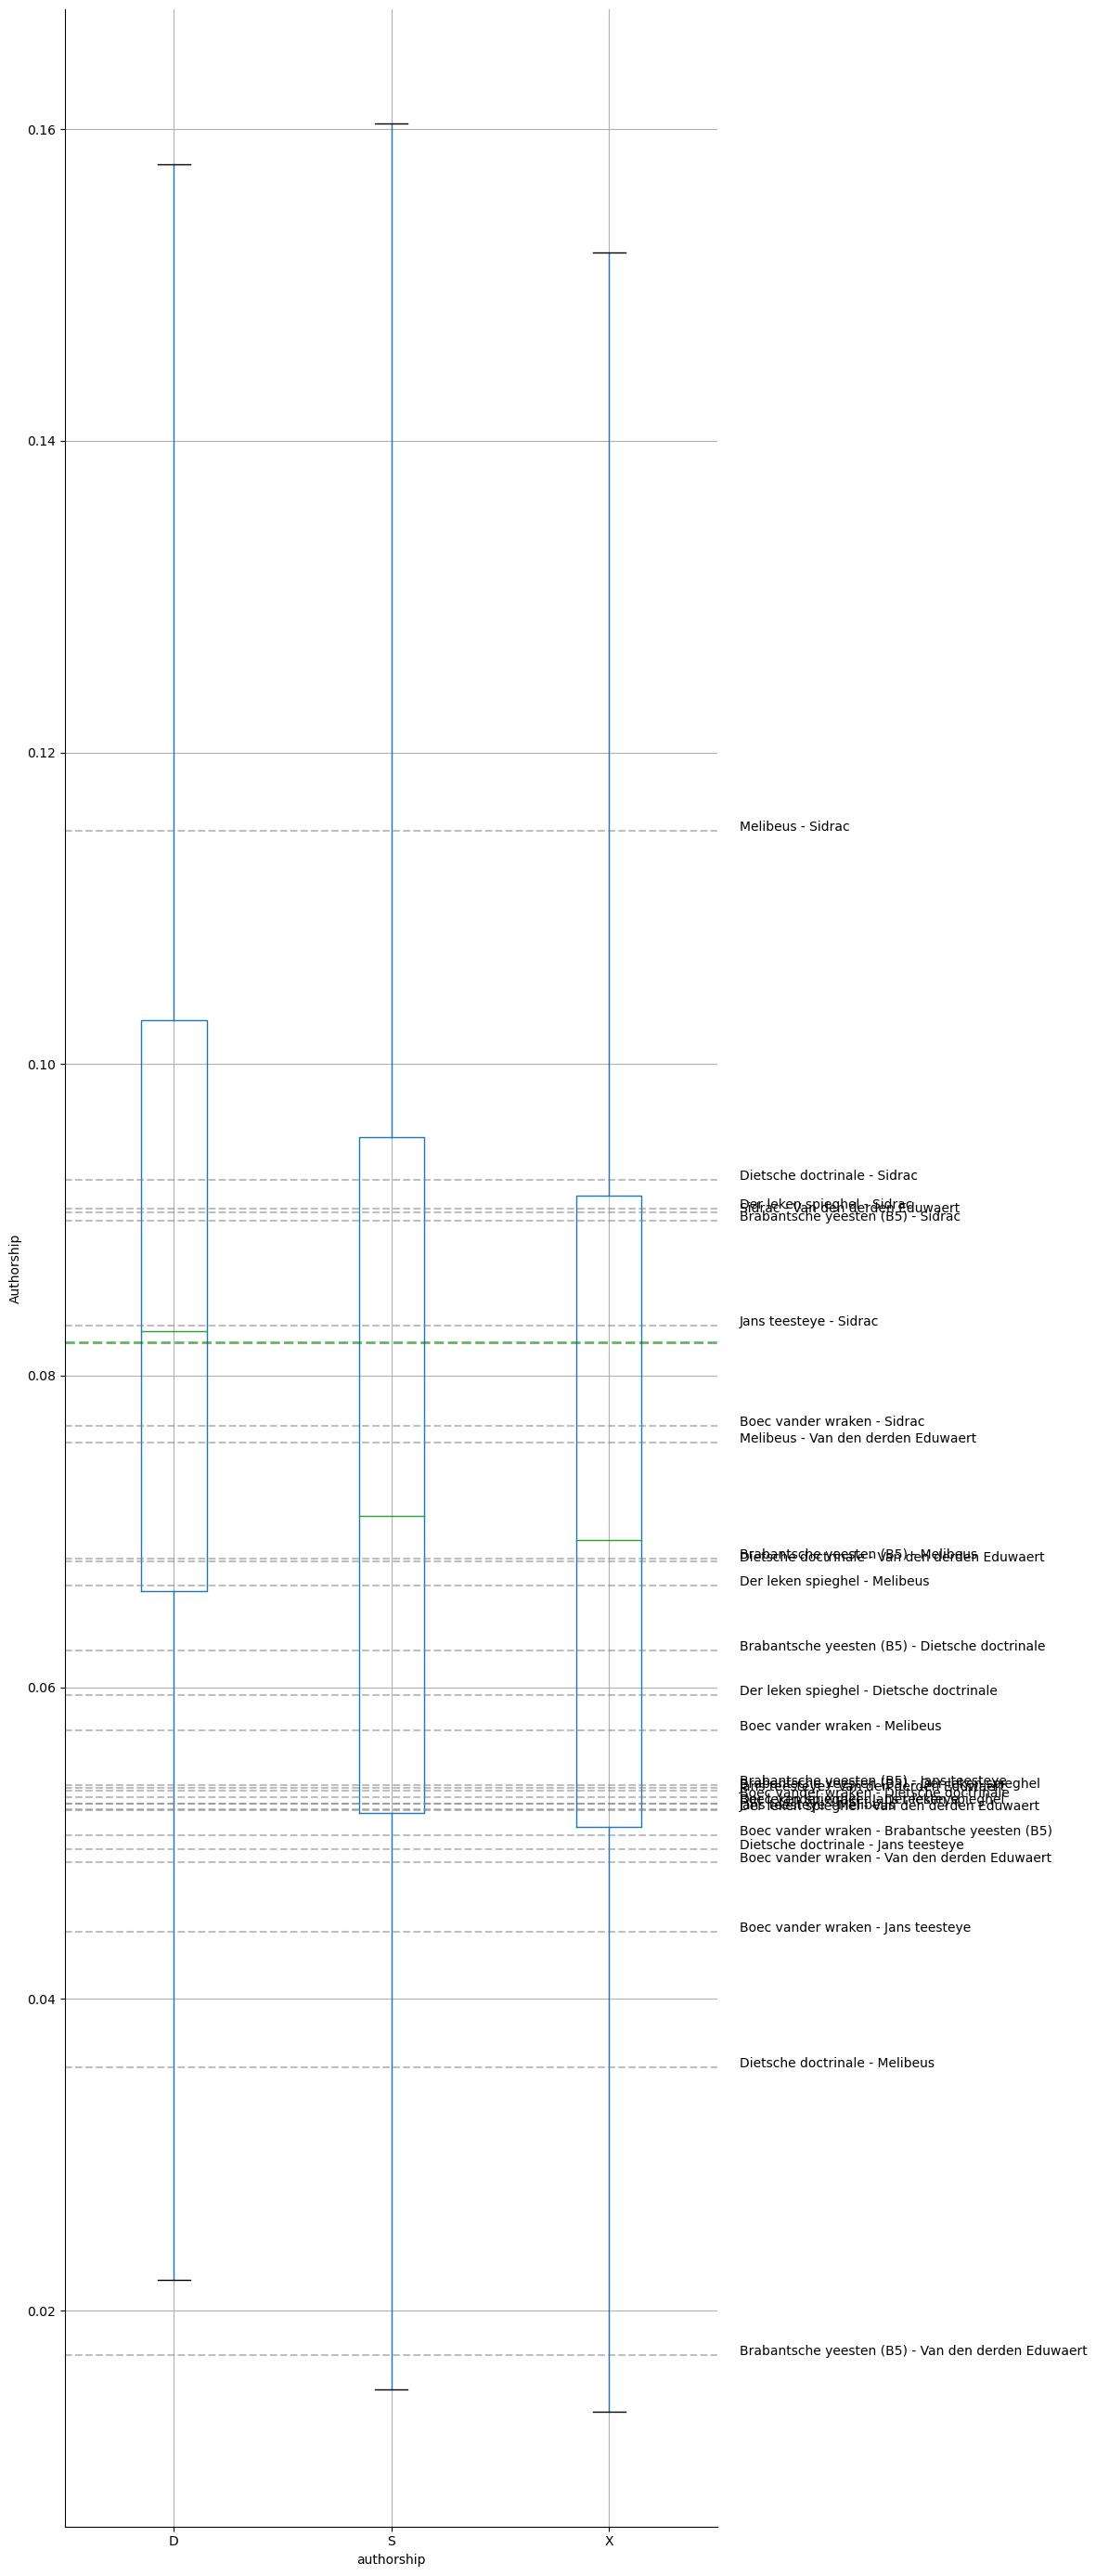

In [19]:
trg_X = vectorizer.transform(trg_df['text'].astype(str).tolist()).toarray()

combos = pd.DataFrame(combinations(trg_df['title'].unique(), 2), columns=['title1', 'title2'])
combos['authorship'] = 'X'

trg_distances = []

for idx, row in combos.iterrows():
    AX = trg_X[trg_df['title'] == row['title1']]
    BX = trg_X[trg_df['title'] == row['title2']]
    
    for distance in scidist.cdist(AX, BX, metric='cosine').flatten():
        trg_distances.append((row['title1'], row['title2'], row['authorship'], distance))

trg_distances = pd.DataFrame(trg_distances, columns=['title1', 'title2', 'authorship', 'distance'])
distances = pd.concat([calib_distances, trg_distances])

distances.boxplot('distance', 'authorship', figsize=(12, 28), showfliers=False)
sb.despine()
plt.axhline(calib_thresh, c='green', linewidth=2, ls='--', alpha=.6)

for grouper, group in distances.groupby('authorship'):
    if grouper == 'X':
        for m, d in group.groupby(['title1', 'title2'])['distance']:
            plt.gca().axhline(d.mean(), c='grey', ls='--', alpha=.5)
            plt.annotate(' - '.join(m), xy=[plt.gca().get_xlim()[1]+0.1, d.mean()],
                         annotation_clip=False)
            
plt.title('')
plt.ylabel('Distance')
plt.ylabel('Authorship')
plt.suptitle('')

plt.tight_layout();

## Dimensionality Reduction

In [20]:
import umap.umap_ as umap

def scatterplot(X, df, label_column=None, color_column=None):
    if color_column:
        ints = [int(i) for i in LabelEncoder().fit_transform([str(i) for i in df[color_column]])]
        colors = sb.color_palette('husl', n_colors=len(set(ints)))
    else:
        ints = AgglomerativeClustering(n_clusters=8).fit_predict(X)
        colors = sb.color_palette('husl', n_colors=8)
    
    colors = [tuple([int(c * 256) for c in color]) for color in colors]
    
    meta_fields = ['title', 'genre', 'subgenre']
    d = {c:list(df[c]) for c in meta_fields}
    d['color'] = ['#%02x%02x%02x' % colors[i] for i in ints]
    d['x'] = X[:, 0]
    d['y'] = X[:, 1]
    source = ColumnDataSource(data=d)

    TOOLS="pan,wheel_zoom,reset,hover,box_select,save"

    p = figure(title='Embeddings',
               tools=TOOLS,
               width=1000,
               height=800,
               outline_line_color="white")

    p.circle(x='x', y='y', color='color',
             source=source, size=8,
             fill_alpha=0.9, line_color=None)
    
    if label_column:
        for label, x, y in zip(df[label_column], d['x'], d['y']):
            if isinstance(label, str):
                p.text(x, y, text=[label], text_align="center", text_font_size="5pt")

    hover = p.select(dict(type=HoverTool))
    hover.tooltips = [(c, '@'+c) for c in meta_fields]
    
    p.xgrid.grid_line_color = None
    p.ygrid.grid_line_color = None
    p.axis.axis_line_color = None
    p.axis.major_label_text_font_size = '0pt'

    # Turn off tick marks
    p.axis.major_tick_line_color = None
    p.axis[0].ticker.num_minor_ticks = 0
    p.axis[1].ticker.num_minor_ticks = 0
    
    show(p)
    
    return p

sub_df = segment_df[segment_df['subgenre'].isin({'Didactiek', 'Historiografie', 'Proza'})]
sub_df = sub_df[~sub_df['title'].isin({'Vlaamse Rose', 'Arturs doet', 'Merlijn-continuatie', 'Queeste van den Grale', 'Lancelot'})]
sub_df['text'] = sub_df['text'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))

# Option to limit amount of segments in the plot (option 3)
sub_df = sub_df.groupby('title').apply(lambda x: x.sample(n=min(len(x), 25), random_state=42)).reset_index(drop=True)

params = {'use_idf': True,
          'max_features': 100,
          'analyzer': unigrams,
          'min_df': 5,
         }

vectorizer = TfidfVectorizer(**params)
BOW = vectorizer.fit_transform(sub_df['text']).toarray()
pca = PCA(n_components=20)
X = pca.fit_transform(BOW)

#tsne = TSNE(n_components=2)
#X = tsne.fit_transform(X)

umap_model = umap.UMAP(n_components=2, random_state=1, n_neighbors=20, min_dist=0.20)
#umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.20)

X = umap_model.fit_transform(X)

plot = scatterplot(X, sub_df, label_column='title', color_column='title')
plot

/Users/carolinevandyck/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


figure(id='p1004', ...)

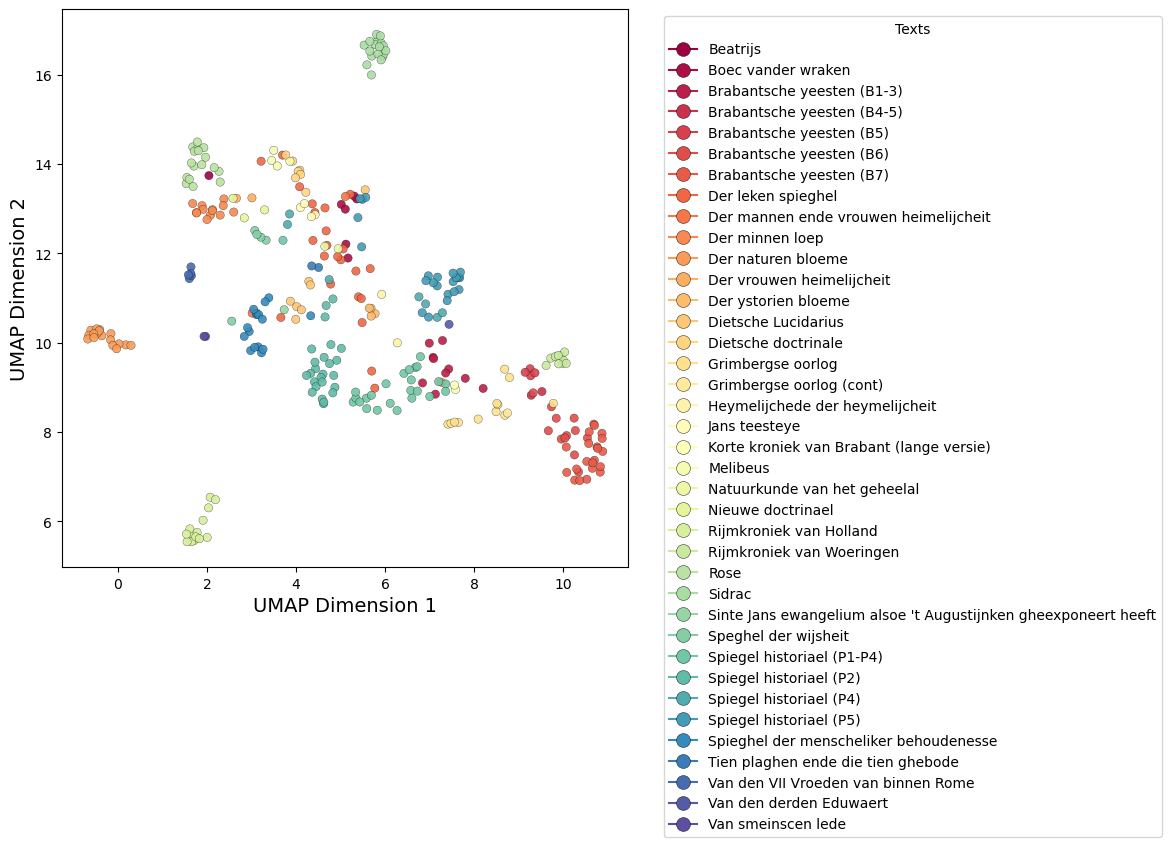

In [21]:
import umap.umap_ as umap

# Perform dimensionality reduction with PCA
pca_model = PCA(n_components=20)
X_pca = pca_model.fit_transform(BOW)

# Further reduction with UMAP
umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.20)#, n_neighbors=15, min_dist=0.1)
X_umap = umap_model.fit_transform(X_pca)

# Label encoding for scribes to color the scatter plot
label_encoder = LabelEncoder()
colors = label_encoder.fit_transform(sub_df['title'])

# Create a scatter plot with Matplotlib
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=colors, cmap='Spectral', alpha=0.9, edgecolor='black', linewidth=0.2)

# Creating a custom legend that matches the colors of the dots
text_labels = label_encoder.classes_
legend_handles = [plt.Line2D([0], [0], marker='o', color=scatter.cmap(scatter.norm(color)), label=f'{text}', markersize=10, markeredgecolor='black', markeredgewidth=0.3) for color, text in enumerate(text_labels)]

# Place the legend outside the plot on the right side, with a frame
plt.legend(handles=legend_handles, title="Texts", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

# Adding titles and labels with enhanced fonts
plt.xlabel('UMAP Dimension 1', fontsize=14)
plt.ylabel('UMAP Dimension 2', fontsize=14)
plt.grid(False)
plt.tight_layout()
#plt.savefig('../figures/scatterplot_with_legend_sidrac.svg', dpi=600, bbox_inches='tight')
plt.show()

In [22]:
import plotly.express as px
import pandas as pd

# Map categorical titles to a numeric scale for coloring
sub_df['title_numeric'] = pd.Categorical(sub_df['title']).codes

# Add UMAP coordinates back to the dataframe for ease of access
sub_df['UMAP Dimension 1'] = X_umap[:, 0]
sub_df['UMAP Dimension 2'] = X_umap[:, 1]

# Use a color scale based on the numeric mapping of titles
fig = px.scatter(sub_df, x='UMAP Dimension 1', y='UMAP Dimension 2', 
                 color='title_numeric', hover_data=['title'], 
                 labels={'title': 'title'}, 
                 color_continuous_scale='Spectral')  # You can change 'Viridis' to any other scale

# Add title and axis labels
fig.update_layout(title='UMAP Scatter Plot of Charter Texts by Scribes',
                  xaxis_title='UMAP Dimension 1',
                  yaxis_title='UMAP Dimension 2',
                  width=800,  # Adjust width
                  height=600,  # Adjust height to make it square
                  margin=dict(l=40, r=40, t=40, b=40)  # Adjust margins to avoid clipping
)

# Show interactive plot
fig.show()

In [23]:
# Want to include another text in sub_df? sub_df = segment_df[segment_df['title'].isin({''})]
sub_df = trg_df
sub_df['text'] = sub_df['text'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))

vectorizer = TfidfVectorizer(**params)
BOW = vectorizer.fit_transform(sub_df['text']).toarray()
BOW = StandardScaler().fit_transform(BOW)

/var/folders/qv/jgq1ttws58g43xdmt2gthgth0000gn/T/ipykernel_66427/1535423603.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



## PCA

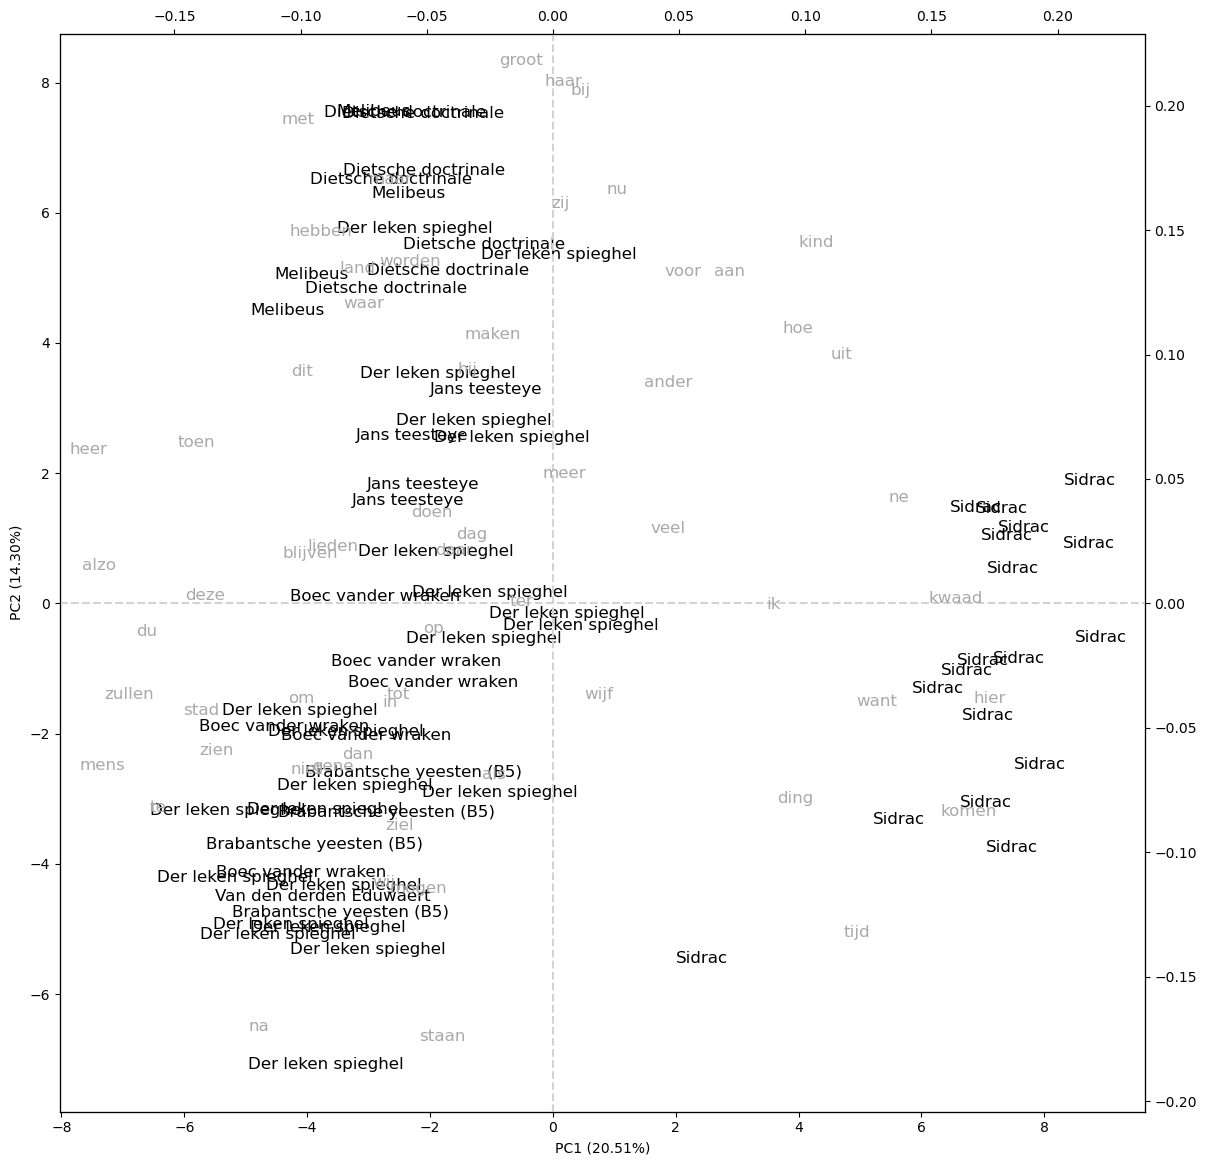

In [24]:
def plot_pca(document_proj, loadings, var_exp, labels):
    # first the texts:
    fig, text_ax = plt.subplots(figsize=(14, 14))
    x1, x2 = documents_proj[:, 0], documents_proj[:, 1]
    text_ax.scatter(x1, x2, facecolors='none')
    for p1, p2, label in zip(x1, x2, labels):
        text_ax.text(p1, p2, label, ha='center', va='center', fontsize=12)

    # add variance information to the axis labels:
    text_ax.set_xlabel(f'PC1 ({var_exp[0] * 100:.2f}%)')
    text_ax.set_ylabel(f'PC2 ({var_exp[1] * 100:.2f}%)')
    
    # now the loadings:
    loadings_ax = text_ax.twinx().twiny()
    l1, l2 = loadings[:, 0], loadings[:, 1]
    lc = l1 * l2
    m = 60
    top_idxs = lc.argsort()[::-1][:m]
    
    loadings_ax.scatter(l1[top_idxs], l2[top_idxs], facecolors='none');
    for x, y, loading in zip(l1, l2, np.array(vectorizer.get_feature_names_out())[top_idxs]):
        loadings_ax.text(x, y, loading, ha='center', va='center',
                         color='darkgrey', fontsize=12)

    mpl_axes_aligner.align.yaxes(text_ax, 0, loadings_ax, 0)
    mpl_axes_aligner.align.xaxes(text_ax, 0, loadings_ax, 0)
    
    # add lines through origins:
    plt.axvline(0, ls='dashed', c='lightgrey', zorder=0)
    plt.axhline(0, ls='dashed', c='lightgrey', zorder=0);

# fit the pca:
pca = PCA(n_components=2)
documents_proj = pca.fit_transform(BOW)
loadings = pca.components_.transpose()
var_exp = pca.explained_variance_ratio_

plot_pca(documents_proj, loadings, var_exp, sub_df['title'])

## Hierarchical clustering

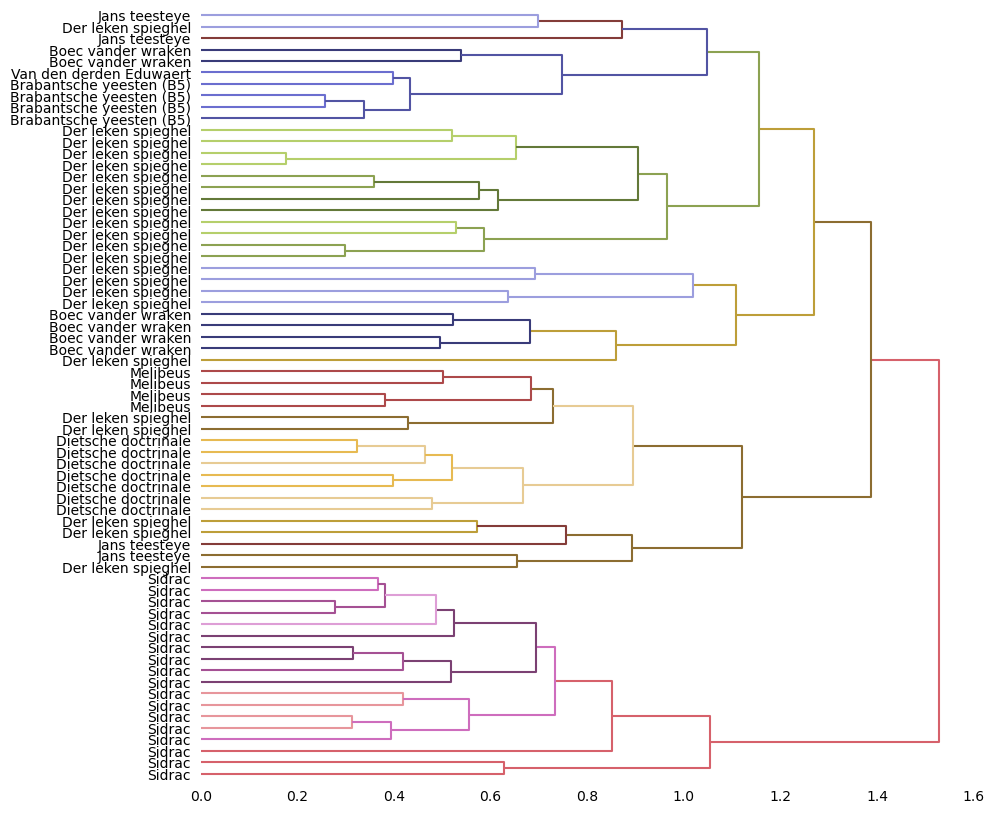

In [25]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as hierarchy
import scipy.spatial.distance as scidist
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Reset index and get labels
trg_reset_df = trg_df.reset_index(drop=True)
labels = trg_reset_df['title'].tolist()

# Calculate pairwise distances and perform linkage
dm = scidist.pdist(BOW, 'cosine')
linkage_object = hierarchy.linkage(dm, method='complete')

# Assign a unique hex color to each leaf node
num_leaves = len(labels)
cmap = plt.colormaps['tab20b'].resampled(num_leaves)
colors = [mcolors.to_hex(cmap(i)) for i in range(num_leaves)]
leaf_colors = {i: colors[i % num_leaves] for i in range(num_leaves)}

# Function to color each branch path from leaves up
def color_func(link_id):
    if link_id < num_leaves:
        return leaf_colors[link_id]
    else:
        # Inherit color from the first child
        left = int(linkage_object[link_id - num_leaves][0])
        return color_func(left)

# Plot dendrogram
def plot_tree(linkage_object, labels, figsize=(10, 10), ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    with plt.rc_context({'lines.linewidth': 1.5}):
        hierarchy.dendrogram(
            linkage_object, 
            labels=labels, 
            ax=ax,
            leaf_font_size=10,
            orientation='right',
            link_color_func=color_func
        )
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    for s in ax.spines.values():
        s.set_visible(False)

plot_tree(linkage_object, labels)

## Verification Ranking

In [26]:
params = {'use_idf': True,
          'max_features': 100,
          'analyzer': unigrams,
          'min_df': 5}

vectorizer = TfidfVectorizer(**params)
epics = segment_df[segment_df['genre'].isin(['Epiek', 'Proza'])].copy().reindex()
epics['text'] = epics['text'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))
vectorizer.fit(epics['text'])
segment_X = vectorizer.transform(epics['text']).toarray()
segment_X.shape

(831, 100)

In [27]:
num_iter = 250
total_features = len(vectorizer.get_feature_names_out())
num_rnd_features = int(total_features * .5)
n_top_neighbors = 5

target_titles = [#'Brabantsche yeesten (B1-3)', 'Brabantsche yeesten (B4-5)',
                 'Korte kroniek van Brabant (lange versie)',
                 'Brabantsche yeesten (B5)', 'Korte kroniek van Brabant (korte versie 1)',
                 'Der leken spieghel', 'Jans teesteye', 'Van den derden Eduwaert', 
                 'Melibeus', 'Boec Exemplaer', 'Dietsche doctrinale', 'Boec vander wraken',
    'Der ystorien bloeme', 'Grimbergse oorlog',
                 'Sidrac'
]

results = []

for target_title in target_titles:
    targets = epics[epics['title'] == target_title]
    candidates = epics[epics['title'] != target_title]
    neighbors = Counter()
    for trg_idx in tqdm(list(targets.index), desc=target_title):
        for i in range(num_iter):
            feats = np.random.choice(total_features, num_rnd_features, replace=False)
            ax = segment_X[trg_idx, feats]
            sampled = candidates.groupby('title').sample(1)
            xx = segment_X[sampled.index][:, feats]
            distances = scidist.cdist([ax], xx, metric='cosine').flatten()
            idxs = distances.argsort()[:1]
            neighbors.update(sampled.iloc[idxs]['title'])
    top_neighbors = neighbors.most_common(n_top_neighbors)
    summed = sum(neighbors.values())
    top_neighbors = [f'{k} ({(v / summed) * 100:.2f}%)' for k, v in top_neighbors]
    
    results.append([target_title] + top_neighbors)
    
results = pd.DataFrame(results, columns=['Target']+[f'Rank {i + 1}' for i in range(n_top_neighbors)])
results

Brabantsche yeesten (B5): 100%|███████████████████| 4/4 [00:00<00:00,  4.36it/s]
Korte kroniek van Brabant (korte versie 1): 0it [00:00, ?it/s]
Melibeus: 100%|███████████████████████████████████| 4/4 [00:00<00:00,  4.29it/s]
Boec Exemplaer: 0it [00:00, ?it/s]
Sidrac: 100%|███████████████████████████████████| 18/18 [00:04<00:00,  4.38it/s]


,Target,Rank 1,Rank 2,Rank 3,Rank 4,Rank 5
0,Korte kroniek van Brabant (lange versie),Brabantsche yeesten (B4-5) (48.00%),Brabantsche yeesten (B1-3) (24.40%),Spiegel historiael (P1-P4) (12.20%),Rijmbijbel (2.80%),Rijmkroniek van Holland (2.20%)
1,Brabantsche yeesten (B5),Van den derden Eduwaert (77.80%),Boec vander wraken (5.90%),Brabantsche yeesten (B4-5) (4.70%),Borchgrave van Couchi (1.90%),Brabantsche yeesten (B1-3) (1.80%)
2,Korte kroniek van Brabant (korte versie 1),None,None,None,None,None
3,Der leken spieghel,Boec vander wraken (18.31%),Jans teesteye (9.72%),Dietsche doctrinale (7.58%),Melibeus (5.29%),Brabantsche yeesten (B5) (4.40%)
4,Jans teesteye,Boec vander wraken (23.70%),Der leken spieghel (12.40%),Der minnen loep (8.50%),Dietsche doctrinale (7.30%),Melibeus (6.40%)
5,Van den derden Eduwaert,Brabantsche yeesten (B5) (64.00%),Brabantsche yeesten (B1-3) (15.20%),Brabantsche yeesten (B4-5) (4.80%),Boec vander wraken (4.40%),Spiegel historiael (P5) (4.00%)
6,Melibeus,Dietsche doctrinale (55.30%),Jans teesteye (9.60%),Der leken spieghel (5.80%),Boec vander wraken (5.60%),Rose (4.00%)
7,Boec Exemplaer,None,None,None,None,None
8,Dietsche doctrinale,Melibeus (52.06%),Jans teesteye (14.57%),Boec vander wraken (9.71%),Der leken spieghel (8.06%),Der minnen loep (1.94%)
9,Boec vander wraken,Brabantsche yeesten (B5) (17.47%),Der leken spieghel (14.73%),Van den derden Eduwaert (11.20%),Jans teesteye (10.87%),Dietsche doctrinale (7.13%)


## Feature analysis

On the Antwerp School (vs. all Middle Dutch epics)

In [28]:
BOW = pd.DataFrame(segment_X, columns=vectorizer.get_feature_names_out())
BOW.index = epics['title'].isin([#'Brabantsche yeesten (B1-3)', 'Brabantsche yeesten (B4-5)',
                                 'Brabantsche yeesten (B5)',
                                 'Korte kroniek van Brabant (korte versie 1)',
                                 'Korte kroniek van Brabant (lange versie)',
                                 'Der leken spieghel', 'Jans teesteye', 
                                 'Van den derden Eduwaert', 'Melibeus', 'Boec Exemplaer', 
                                 'Dietsche doctrinale', 'Boec vander wraken', 'Sidrac'])

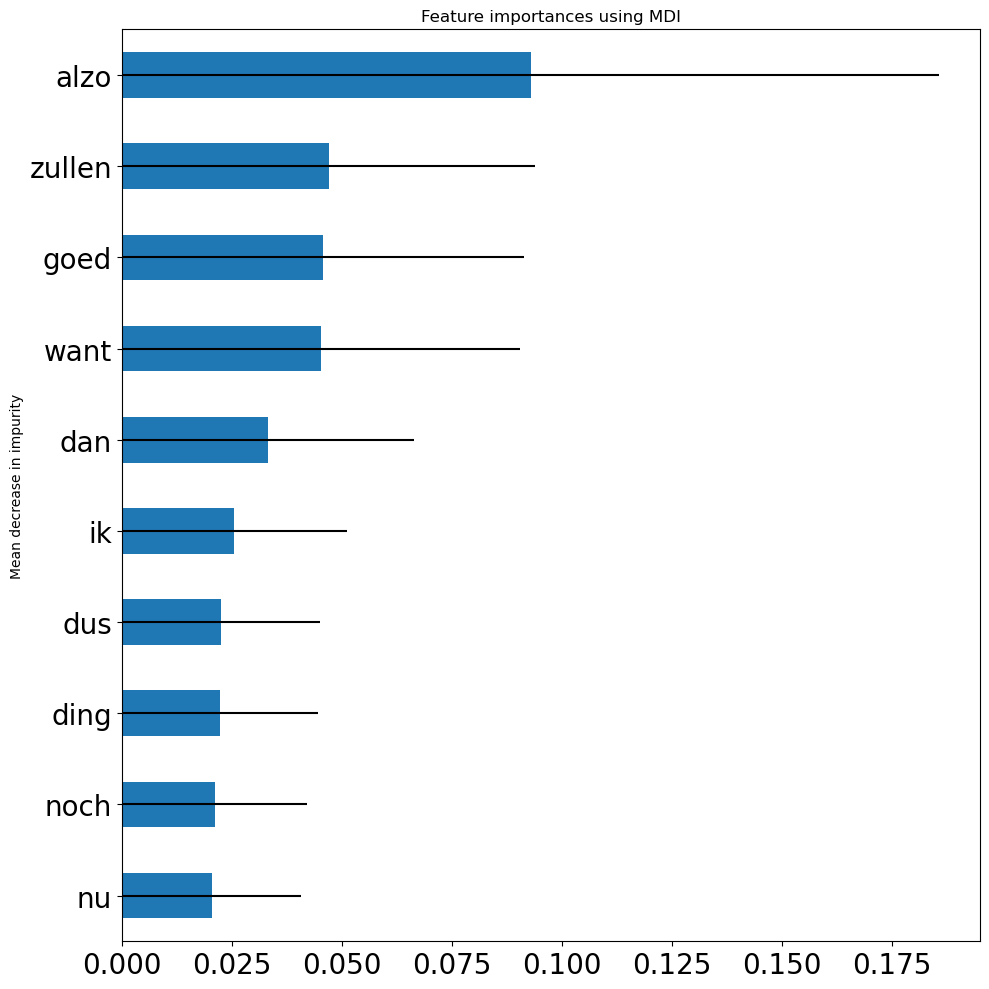

In [29]:
classes = BOW.index

feature_names = vectorizer.get_feature_names_out()
forest = RandomForestClassifier(random_state=0)
forest.fit(BOW, classes)

importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)

cutoff = 10
forest_importances = pd.Series(importances, index=feature_names)
std = pd.Series(std, index=feature_names)
forest_importances = forest_importances.sort_values(ascending=False).head(cutoff)[::-1]
std = forest_importances.loc[forest_importances.index].head(cutoff)[::-1]

fig, ax = plt.subplots(figsize=(10, 10))
forest_importances.plot.barh(xerr=std, ax=ax, fontsize=20)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

/Users/carolinevandyck/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning:

The figure layout has changed to tight



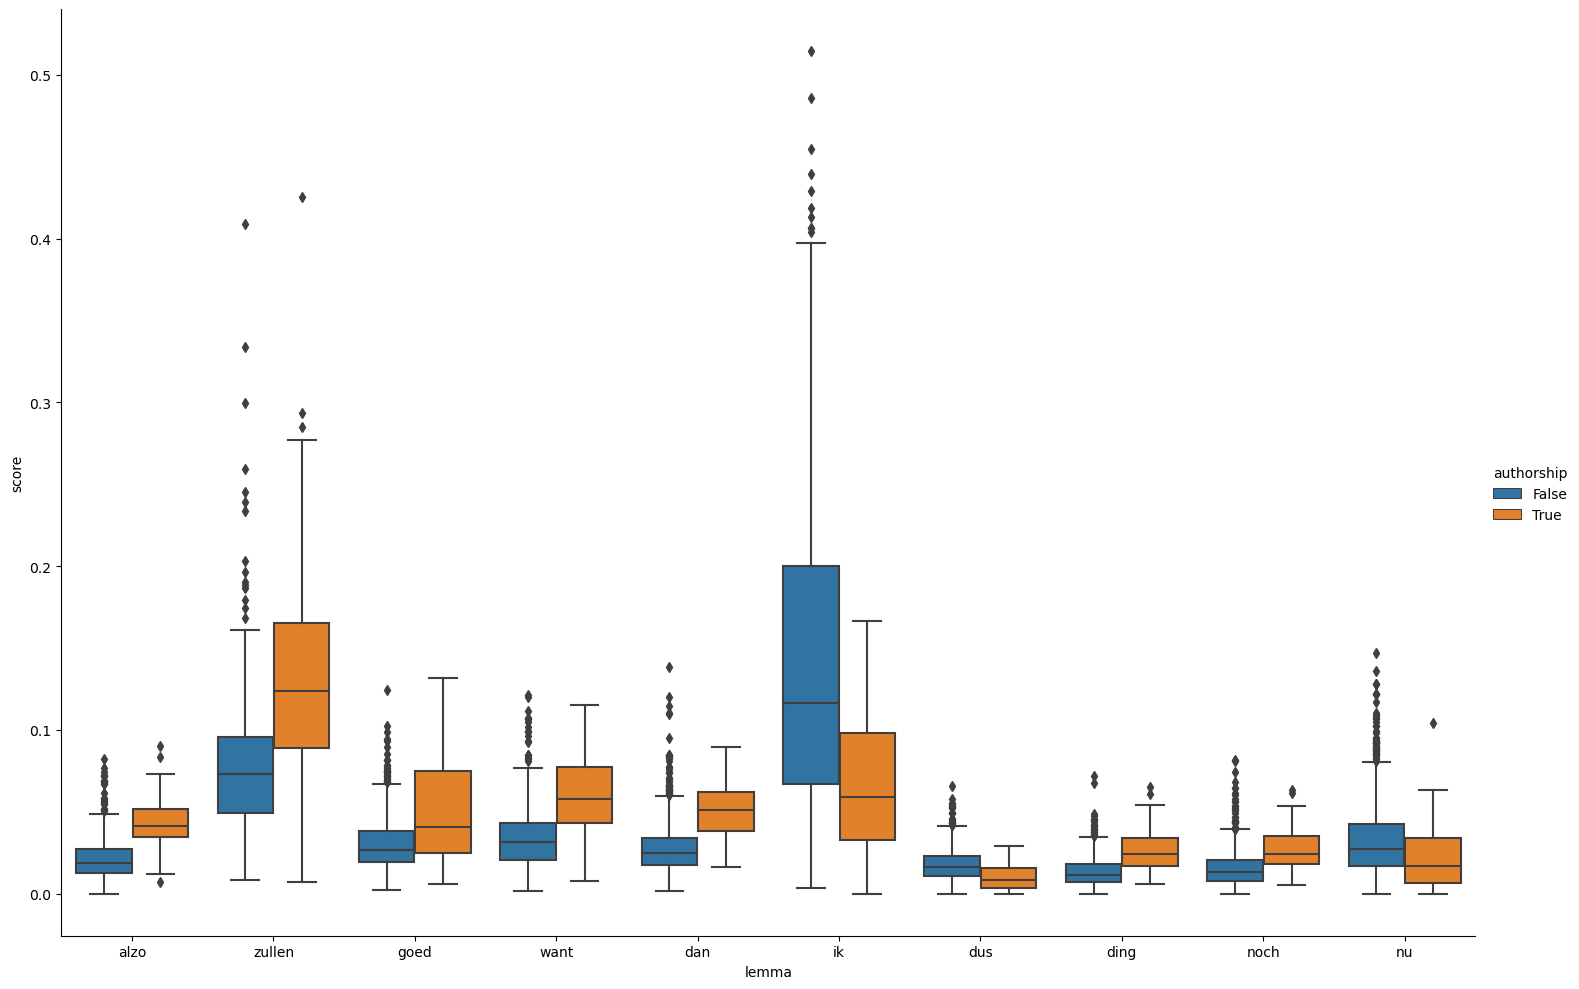

In [30]:
BOW = BOW[forest_importances.index[::-1]]
BOW.index = classes
bow = pd.melt(BOW, value_vars=BOW.columns, ignore_index=False, var_name='lemma', value_name='score')
bow = bow.reset_index()
bow['authorship'] = bow['title']
sb.catplot(x="lemma", hue="authorship", y="score", data=bow, kind='box', height=10, aspect=1.5);

## Sidrac

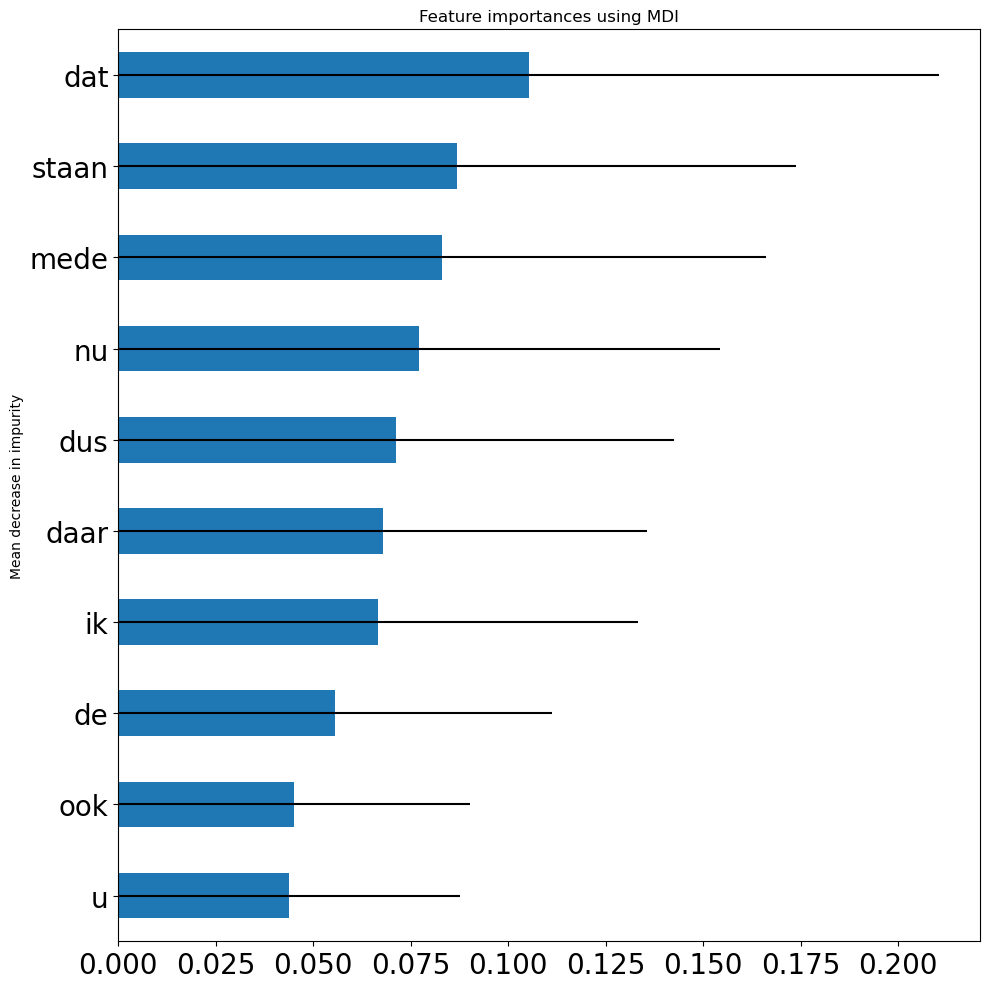

In [31]:
epics = epics[epics['title'].isin([#'Brabantsche yeesten (B1-3)', 'Brabantsche yeesten (B4-5)',
                                   'Brabantsche yeesten (B5)', 'Korte kroniek van Brabant (korte versie 1)',
                 'Der leken spieghel', 'Jans teesteye', 'Van den derden Eduwaert', 
                 'Melibeus', 'Boec Exemplaer', 'Dietsche doctrinale', 'Boec vander wraken', 'Sidrac'])]
segment_X = vectorizer.transform(epics['text']).toarray()

BOW = pd.DataFrame(segment_X, columns=vectorizer.get_feature_names_out())
BOW.index = epics['title'] == 'Sidrac'

classes = BOW.index

feature_names = vectorizer.get_feature_names_out()
forest = RandomForestClassifier(random_state=0)
forest.fit(BOW, classes)

importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)

cutoff = 10
forest_importances = pd.Series(importances, index=feature_names)
std = pd.Series(std, index=feature_names)
forest_importances = forest_importances.sort_values(ascending=False).head(cutoff)[::-1]
std = forest_importances.loc[forest_importances.index].head(cutoff)[::-1]

fig, ax = plt.subplots(figsize=(10, 10))
forest_importances.plot.barh(xerr=std, ax=ax, fontsize=20)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

/Users/carolinevandyck/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning:

The figure layout has changed to tight



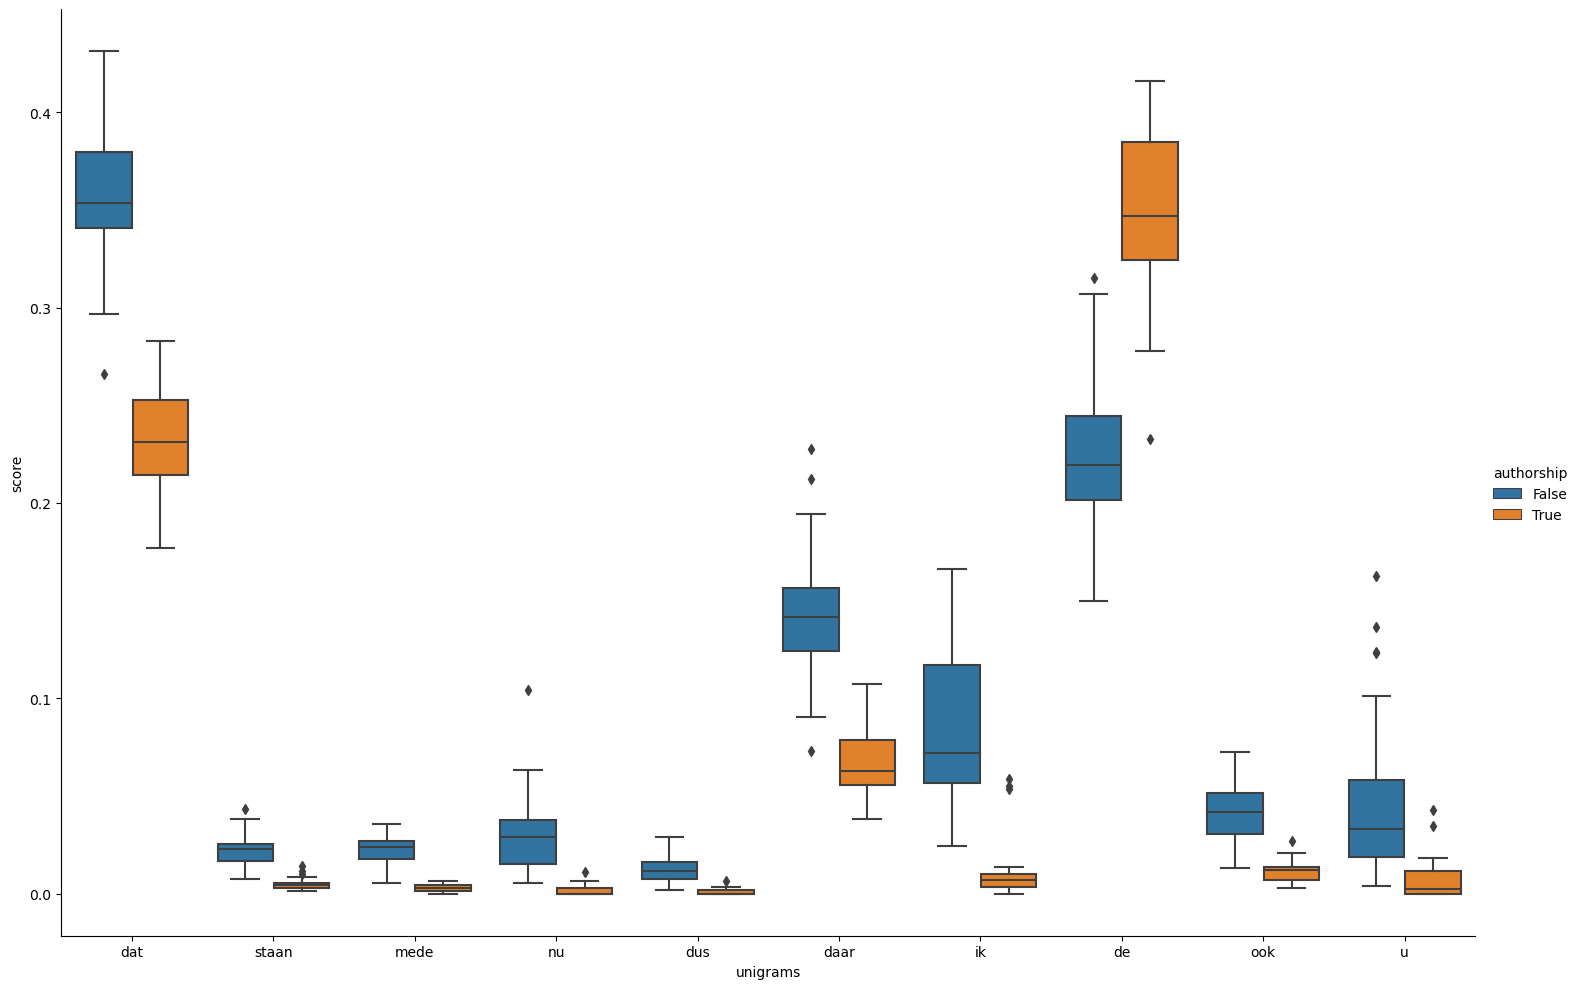

In [32]:
BOW = BOW[forest_importances.index[::-1]]
BOW.index = classes
bow = pd.melt(BOW, value_vars=BOW.columns, ignore_index=False, var_name='unigrams', value_name='score')
bow = bow.reset_index()
bow['authorship'] = bow['title']
sb.catplot(x="unigrams", hue="authorship", y="score", data=bow, kind='box', height=10, aspect=1.5);